# ThresholdPlot

`ThresholdPlot` evaluates a comfort model across a 2-D grid of input conditions and colours each region according to where the output falls. This makes it easy to see which combinations of inputs, for example dry-bulb air temperature and relative humidity, land inside or outside a comfort zone, without manually running the model for every point.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pythermalcomfort.models import heat_index_rothfusz, pmv_ppd_iso, utci
from pythermalcomfort.plots.matplotlib import ThresholdPlot

## 1. Air Temperature vs Relative Humidity

The most common axis pairing for indoor comfort. At typical office conditions (sedentary activity, light clothing, still air), relative humidity plays a secondary role — the boundary between comfortable and warm shifts only slightly with humidity, which the chart makes immediately visible.

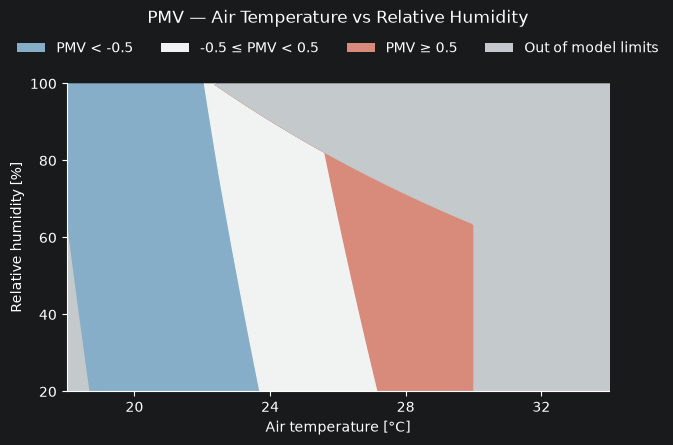

In [2]:
pmv_rh = (
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=18.0, max_val=34.0)
    .set_y_axis(name="rh", min_val=20.0, max_val=100.0)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="PMV — Air Temperature vs Relative Humidity")
)
pmv_rh.ax.set_xlabel("Air temperature [°C]")
pmv_rh.ax.set_ylabel("Relative humidity [%]")
plt.show()

## 2. Air Temperature vs Air Speed

Air movement removes heat from the skin, which shifts the upper comfort boundary to the right as air speed increases. This plot is useful for ventilation design: it shows the minimum air speed needed to keep conditions comfortable at a given temperature. The mean radiant temperature is automatically linked to dry-bulb temperature (tr = tdb).

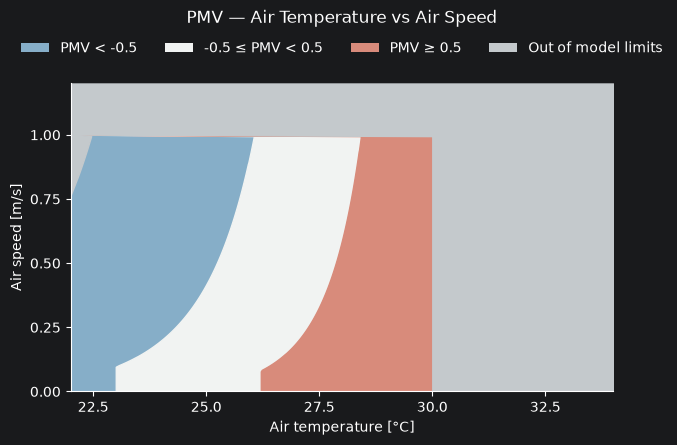

In [3]:
pmv_vr = (
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=22.0, max_val=34.0)
    .set_y_axis(name="vr", min_val=0.0, max_val=1.2)
    .set_params(rh=50, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="PMV — Air Temperature vs Air Speed")
)
pmv_vr.ax.set_xlabel("Air temperature [°C]")
pmv_vr.ax.set_ylabel("Air speed [m/s]")
plt.show()

## 3. Custom Labels and Colors

Pass `labels` and `colors` to `set_regions` to override the auto-generated region names and the default colour palette. This example deliberately uses a muted blue-gray-red alternative; PMV examples that do not demonstrate customization use the default blue, neutral-gray, and terracotta palette. The label list must have exactly `len(thresholds) + 1` entries.

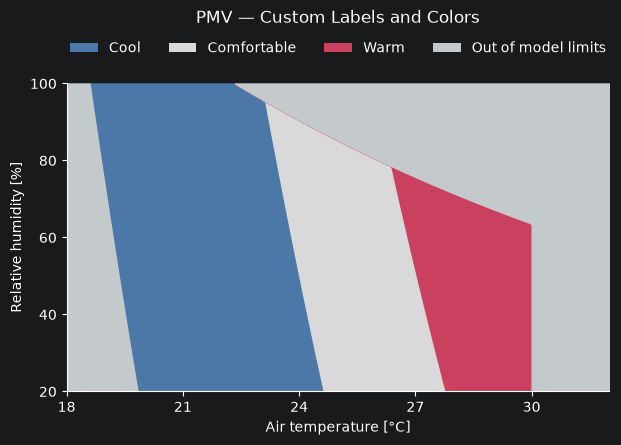

In [4]:
pmv_custom = (
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=18.0, max_val=32.0)
    .set_y_axis(name="rh", min_val=20.0, max_val=100.0)
    .set_params(vr=0.20, met=1.2, clo=0.5, wme=0.0)
    .set_regions(
        output="pmv",
        thresholds=[-0.5, 0.5],
        labels=["Cool", "Comfortable", "Warm"],
        colors=["#4c78a8", "#d9d9d9", "#c9415f"],
    )
    .plot(title="PMV — Custom Labels and Colors")
)
pmv_custom.ax.set_xlabel("Air temperature [°C]")
pmv_custom.ax.set_ylabel("Relative humidity [%]")
plt.show()

## 4. Styling Boundary Lines, Fills, and the Legend

`line_kws`, `fill_kws`, and `legend_kws` are forwarded directly to `ax.plot`, the region fill, and `ax.legend`. Use them to match any figure style without subclassing or post-processing.

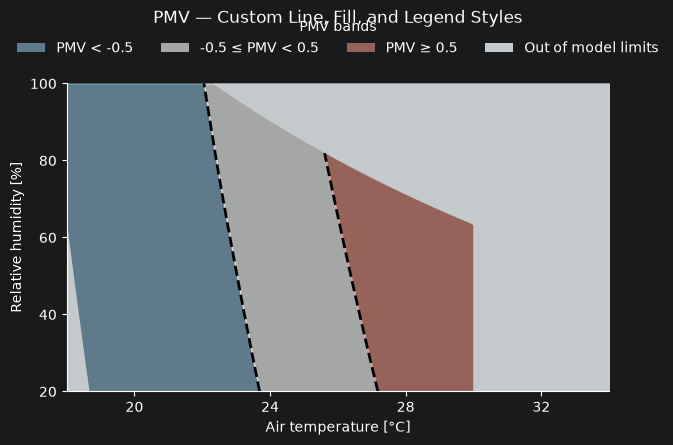

In [5]:
pmv_styled = (
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=18.0, max_val=34.0)
    .set_y_axis(name="rh", min_val=20.0, max_val=100.0)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(
        title="PMV — Custom Line, Fill, and Legend Styles",
        show_lines=True,
        line_kws={"color": "black", "linewidth": 2.0, "linestyle": "dashed"},
        fill_kws={"alpha": 0.65},
        legend_kws={
            "title": "PMV bands",
            "ncol": 4,
        },
    )
)
pmv_styled.ax.set_xlabel("Air temperature [°C]")
pmv_styled.ax.set_ylabel("Relative humidity [%]")
plt.show()

## 5. Out-of-Model Areas

PMV ISO is only defined within a specific range of input conditions. Grid cells where the model returns `NaN` are shown in a separate colour and appear in the legend as 'Out of model limits'. Pass `invalid_color` to choose any Matplotlib-compatible colour.

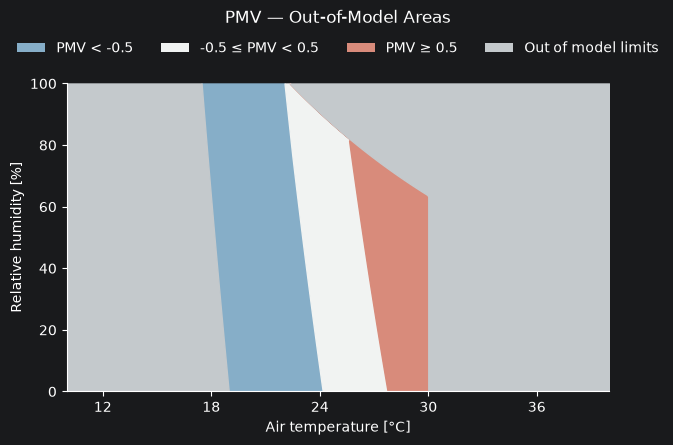

In [6]:
pmv_limits = (
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=10.0, max_val=40.0)
    .set_y_axis(name="rh", min_val=0.0, max_val=100.0)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="PMV — Out-of-Model Areas")
)
pmv_limits.ax.set_xlabel("Air temperature [°C]")
pmv_limits.ax.set_ylabel("Relative humidity [%]")
plt.show()

## 6. UTCI — Air Temperature vs Wind Speed

UTCI is designed for outdoor thermal environments where wind is a primary variable. Plotting air temperature against wind speed — at a fixed humidity and with mean radiant temperature linked to air temperature — shows how wind speed reduces heat stress in hot conditions. Region labels follow the official UTCI thermal stress scale.

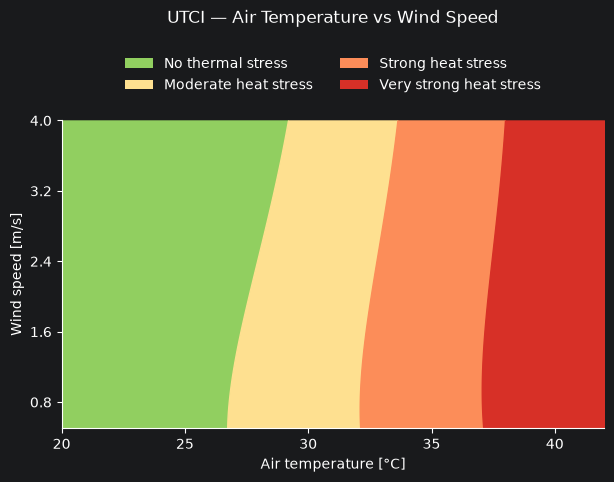

In [7]:
utci_result = (
    ThresholdPlot(model_func=utci)
    .set_x_axis(name="tdb", min_val=20.0, max_val=42.0)
    .set_y_axis(name="v", min_val=0.5, max_val=4.0)
    .set_params(rh=40)  # tr auto-linked to tdb
    .set_regions(
        output="utci",
        thresholds=[26, 32, 38],
        labels=[
            "No thermal stress",
            "Moderate heat stress",
            "Strong heat stress",
            "Very strong heat stress",
        ],
        colors=["#91cf60", "#fee090", "#fc8d59", "#d73027"],
    )
    .plot(
        title="UTCI — Air Temperature vs Wind Speed",
        legend_kws={"ncol": 2},
    )
)
utci_result.ax.set_xlabel("Air temperature [°C]")
utci_result.ax.set_ylabel("Wind speed [m/s]")
plt.show()

## 7. Heat Index

The Rothfusz heat index formula gives an apparent temperature at high humidity. The five regions follow the NWS risk scale. Boundary lines are off by default, which suits a sequential ramp like this one: the colour change already marks each boundary and black lines over five bands read as clutter.

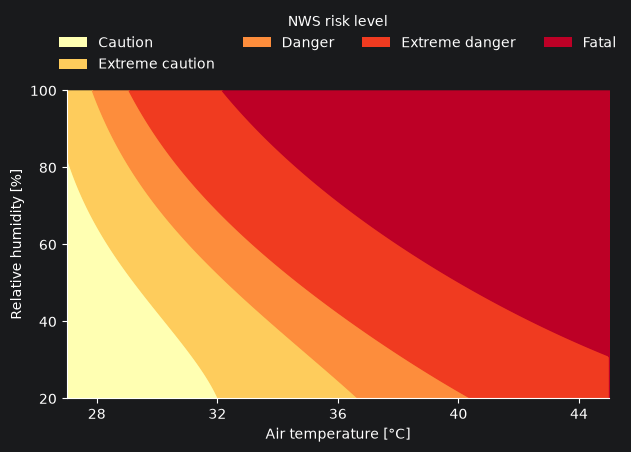

In [8]:
hi_result = (
    ThresholdPlot(model_func=heat_index_rothfusz)
    .set_x_axis(name="tdb", min_val=27.0, max_val=45.0)
    .set_y_axis(name="rh", min_val=20.0, max_val=100.0)
    .set_regions(
        output="hi",
        thresholds=[30.0, 35.0, 40.0, 55.0],
        labels=["Caution", "Extreme caution", "Danger", "Extreme danger", "Fatal"],
        colors=["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"],
    )
    .plot(
        show_lines=False,
        legend_kws={"title": "NWS risk level", "ncol": 3},
    )
)
hi_result.ax.set_xlabel("Air temperature [°C]")
hi_result.ax.set_ylabel("Relative humidity [%]")
plt.show()

## 8. Legend, Boundary Lines, and Applicability Limits

`legend` and `show_lines` are rendering switches; `show_lines=True` draws a line along each threshold boundary, which is off by default. `limit_inputs=False` is a model-level flag passed through `set_params` that disables the model's own applicability check — useful when you want to visualise conditions beyond the standard's defined range.

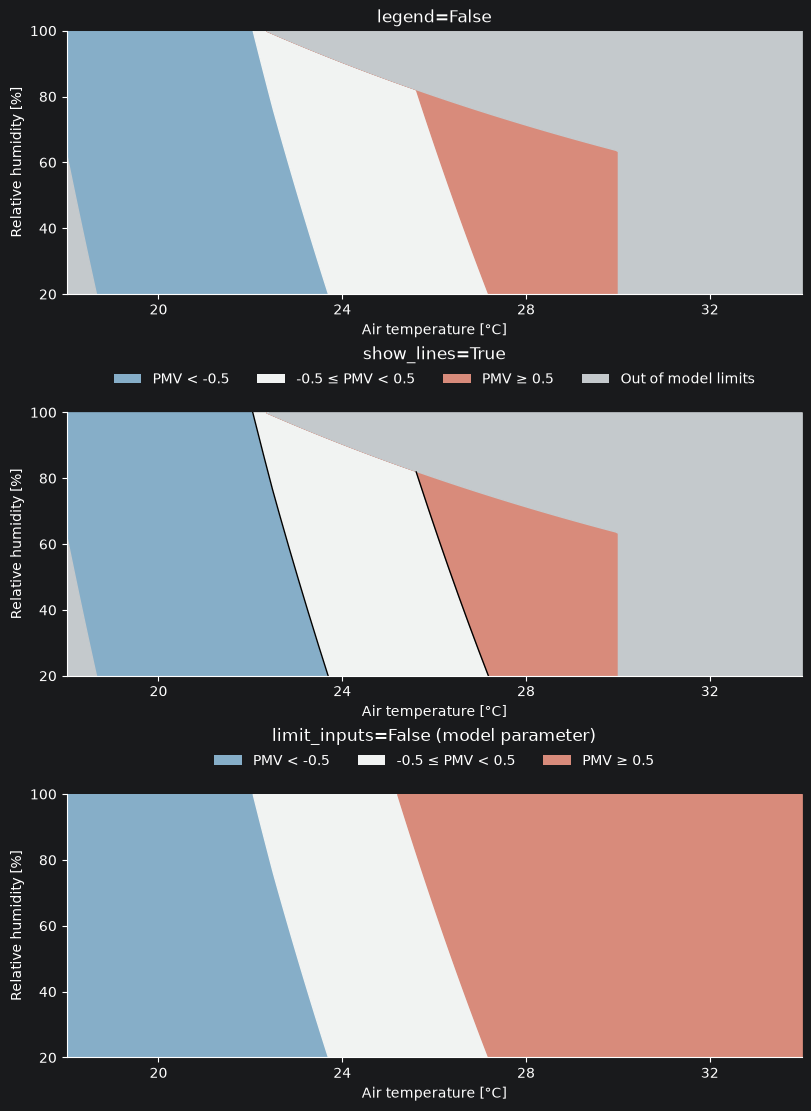

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(8, 11), constrained_layout=True)

(
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=18.0, max_val=34.0)
    .set_y_axis(name="rh", min_val=20.0, max_val=100.0)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=axes[0], title="legend=False", legend=False)
).ax.set(xlabel="Air temperature [°C]", ylabel="Relative humidity [%]")

(
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=18.0, max_val=34.0)
    .set_y_axis(name="rh", min_val=20.0, max_val=100.0)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=axes[1], title="show_lines=True", show_lines=True)
).ax.set(xlabel="Air temperature [°C]", ylabel="Relative humidity [%]")

(
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=18.0, max_val=34.0)
    .set_y_axis(name="rh", min_val=20.0, max_val=100.0)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0, limit_inputs=False)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=axes[2], title="limit_inputs=False (model parameter)")
).ax.set(xlabel="Air temperature [°C]", ylabel="Relative humidity [%]")

plt.show()

## 9. The tr / tdb Parameter Link

When a model accepts both `tdb` and `tr` and you map only one of them to an axis, the other is automatically set to the same per-cell value (operative temperature assumption). Pass `tr=<value>` in `set_params` to override this and fix mean radiant temperature independently.

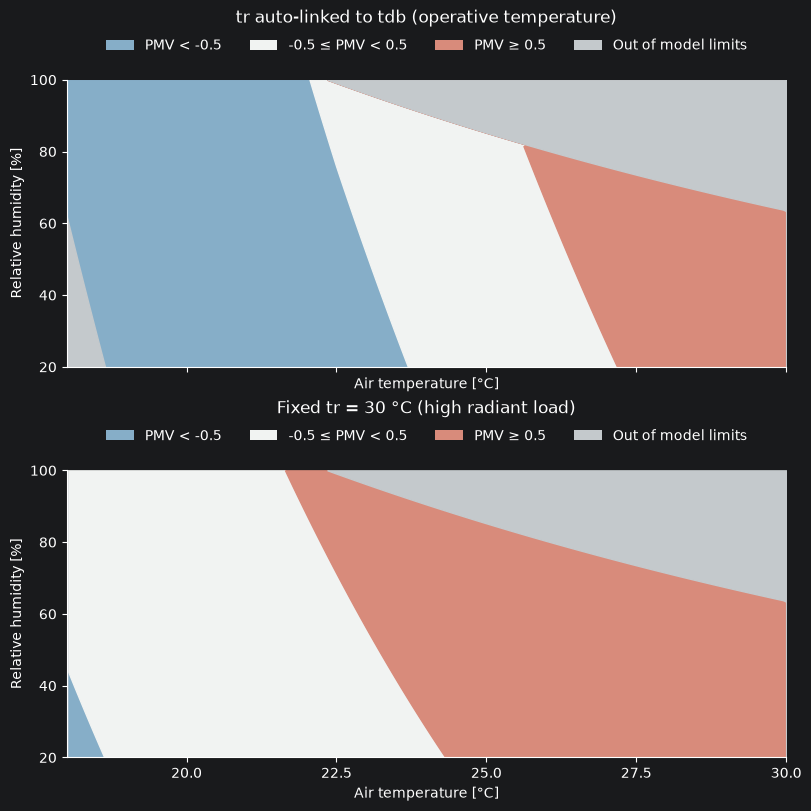

In [10]:
fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(8, 8), constrained_layout=True, sharex=True
)

(
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=18.0, max_val=30.0)
    .set_y_axis(name="rh", min_val=20.0, max_val=100.0)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax0, title="tr auto-linked to tdb (operative temperature)")
).ax.set(xlabel="Air temperature [°C]", ylabel="Relative humidity [%]")

(
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=18.0, max_val=30.0)
    .set_y_axis(name="rh", min_val=20.0, max_val=100.0)
    .set_params(tr=30.0, vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax1, title="Fixed tr = 30 °C (high radiant load)")
).ax.set(xlabel="Air temperature [°C]", ylabel="Relative humidity [%]")

plt.show()

## 10. Modifying Returned Artists

`result.lines`, `result.fills`, and `result.legend` are ordinary Matplotlib artists. Modify them in place after calling `plot()` — useful for per-figure tweaks without restructuring the chain.

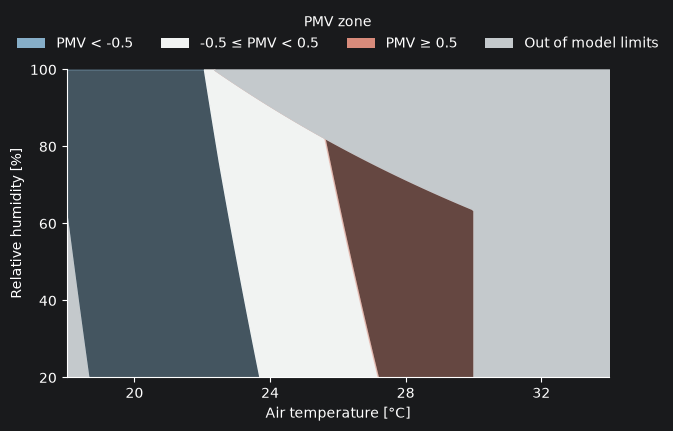

In [11]:
result = (
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=18.0, max_val=34.0)
    .set_y_axis(name="rh", min_val=20.0, max_val=100.0)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot()
)

# Thicken boundary lines
for line in result.lines:
    line.set_linewidth(2.5)

# Reduce fill opacity on the outer regions, keep the comfort zone solid
for fill, alpha in zip(result.fills, [0.4, 1.0, 0.4], strict=False):
    fill.set_alpha(alpha)

# Add a legend title
if result.legend:
    result.legend.set_title("PMV zone")

result.ax.set_xlabel("Air temperature [°C]")
result.ax.set_ylabel("Relative humidity [%]")
plt.show()

## 11. Using result.fig

`result.fig` is the underlying `Figure`. Use it for operations that span the whole figure — super-titles, saving to disk, multi-panel layouts.

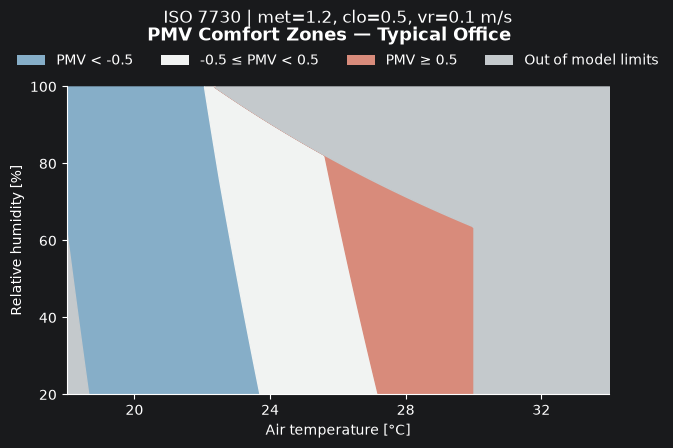

In [12]:
r = (
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=18.0, max_val=34.0)
    .set_y_axis("rh", 20.0, 100.0)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot()
)

r.fig.suptitle(
    "PMV Comfort Zones — Typical Office", y=1.03, fontsize=13, fontweight="bold"
)
r.ax.set_title("ISO 7730 | met=1.2, clo=0.5, vr=0.1 m/s", y=1.18)
r.ax.set_xlabel("Air temperature [°C]")
r.ax.set_ylabel("Relative humidity [%]")

# r.fig.savefig("pmv_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Boundaries as Coordinate Arrays

Boundaries are solved by root-finding, one row of the plot at a time, rather than traced off a raster grid. Three things follow.

First, `resolution` is optional on both axes. It does not set the precision of a boundary — bisection does — so it only matters if a model turns sharply enough that the default sampling could step over a feature. The chart below leaves it out entirely.

Second, the boundaries come back as plain coordinate arrays in `result.boundaries`, so you can re-use them outside the chart. `x` is `NaN` wherever the threshold is not crossed.

Third, a threshold may be crossed more than once along a row, and each crossing gets its own curve, numbered by `branch`. `ppd` is the usual case: it falls to a minimum at neutrality and rises again, so "PPD below 10" is a strip with "above 10" on both sides — five bands drawn from three regions.

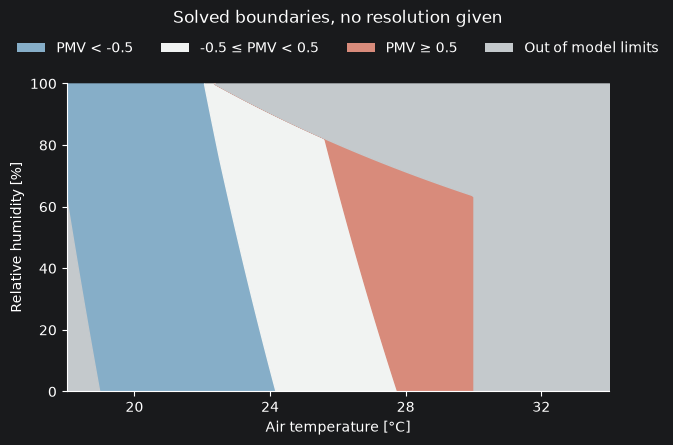

PMV = -0.5 (branch 0): tdb 22.05-24.16 °C over 200 of 200 rows
PMV = +0.5 (branch 0): tdb 25.61-27.75 °C over 164 of 200 rows


In [13]:
no_resolution = (
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=18.0, max_val=34.0)
    .set_y_axis(name="rh", min_val=0.0, max_val=100.0)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="Solved boundaries, no resolution given")
)
no_resolution.ax.set_xlabel("Air temperature [°C]")
no_resolution.ax.set_ylabel("Relative humidity [%]")
plt.show()

for curve in no_resolution.boundaries:
    drawn = np.isfinite(curve.x)
    print(
        f"PMV = {curve.threshold:+.1f} (branch {curve.branch}): "
        f"tdb {curve.x[drawn].min():.2f}-{curve.x[drawn].max():.2f} °C "
        f"over {drawn.sum()} of {curve.x.size} rows"
    )

### A threshold crossed twice

`ppd` against dry-bulb temperature. Each threshold is crossed on both sides of the comfort dip, so each contributes two boundary curves and the outer regions are drawn as two bands apiece.

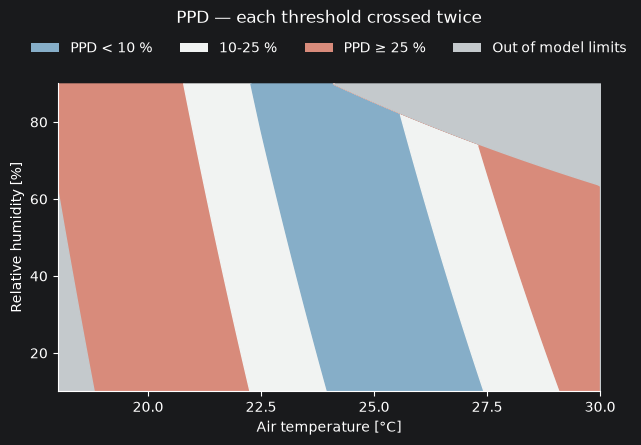

boundary curves: [(10.0, 0), (10.0, 1), (25.0, 0), (25.0, 1)]


In [14]:
ppd_zones = (
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=18.0, max_val=30.0)
    .set_y_axis(name="rh", min_val=10.0, max_val=90.0)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(
        output="ppd",
        thresholds=[10.0, 25.0],
        labels=["PPD < 10 %", "10-25 %", "PPD ≥ 25 %"],
    )
    .plot(title="PPD — each threshold crossed twice")
)
ppd_zones.ax.set_xlabel("Air temperature [°C]")
ppd_zones.ax.set_ylabel("Relative humidity [%]")
plt.show()

print("boundary curves:", [(c.threshold, c.branch) for c in ppd_zones.boundaries])